For the math behind this, see notes from 3/25

In [8]:
from escripts import edata
from escripts import eMCMC
import zeus21
from escripts import eplots

In [ ]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['HST data, Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [79]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [80]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz':{'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [81]:
mass_dependent = [0.818, -0.032, 11.995, 0.05, -1.373, -0.138, 0.992,
0, -0.796, 0.677]
redshift_dependent = [0.49, -0.019, 11.757, -0.04, -1.344, -0.117, 0.527,
0.236, 0, 0.668]
fiducial = [0.531, -0.001, 11.712, -0.057, -1.338, -0.113, 0.486, 0.229,
-0.152, 0.678]

In [115]:
def sfe_with_mean(my_UVLF, param_values, zs = None, Mhtab = None, id_max = False):
    """
    Plot SFE vs. halo mass at different redshifts
    Inputs:
        my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
        param_values [1darray]: values of parameters to calculate SFE
        zs [1darray]: redshifts to plot
        Mhtab [1darray]: log10(Mh) to plot over
        id_max [bool]: Whether or not to identify the maximum SFE at the highest and lowest redshift bin
    Returns:
        fig: A figure showing the SFE over the range of given halo masses & redshifts
    """

    if zs is None:
        zs = np.arange(4, 16, 2)

    if Mhtab is None: 
        Mhtab = np.linspace(9, 13, 200)

    Mhtab_og = my_UVLF.HMFintclass.Mhtab # Save this to reset it later. There's probably a more elegant solution I could come up with at another time
    my_UVLF.HMFintclass.Mhtab = 10**Mhtab # Set the UVLF table of halo masses to the input value
    

    fig = plt.figure(figsize=(6, 4.5))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # narrow right slot for cbar
    ax = fig.add_axes(ax_rect)

    if len(zs)>1:
        cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.yellow, eplots.turquoise], zs)
    
    for z in zs:
        # Calculate parameters at this z
        params = my_UVLF.time_evolution(param_values, z)
        Astro_Parameters = my_UVLF.param_wrapper(params)
        # Calculate SFE
        SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
            Astro_Parameters, my_UVLF.CosmoParams, z, my_UVLF.HMFintclass.Mhtab)
        # Assign color
        if len(zs) > 1:
            frac = (z - min(zs)) / (max(zs) - min(zs))
            color = cmap(frac)
        else:
            color = yellow
        # Plot
        plt.plot(Mhtab, SFEs, color = color, ls = '-', zorder = 0)
        plt.plot(Mhtab, calc_mean_sfe(params, SFEs), color = color, ls = 'dotted', lw = 2)

        if ((z == max(zs) or z==min(zs)) and id_max): # Putting text on the plot indicating the maximum SFE for the highest & lowest redshifts
            max_idx = np.argmax(SFEs) # Maximum /= M_c unless the power law indices are the same!
            plt.scatter(Mhtab[max_idx], SFEs[max_idx], color = color, s = 100, zorder = 1)
            if z==min(zs): # Positioning the text
                x = (Mhtab[max_idx]-0.7)
                y = SFEs[max_idx]-0.01
            else:
                x = Mhtab[max_idx]
                y = 0.6*SFEs[max_idx]
            plt.text(x, y, fr'$f_\star = {round(SFEs[max_idx], 2)}$', color = color, ha = 'center', 
                         va = 'center', size = 17)

    if len(zs)>1:
    # Color bar things:
        cax = fig.add_axes(cax_rect)
        cbar = fig.colorbar(sm, cax=cax, boundaries=boundaries, ticks=zs, aspect = 14)
        cbar.set_label(r'$z$')

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$f_{\star} = \dot M_{\star} / \dot M_{\rm{gas}}$')
    ax.set_yscale('log')

    my_UVLF.HMFintclass.HMFtab = Mhtab_og

    ax.plot(11, 1e-1, color = 'black', label = 'median')
    ax.plot(11, 1e-1, color = 'black', ls= 'dotted', lw = 2, label = 'mean')

    ax.legend()
        
        
    return fig


In [116]:
def calc_mean_sfe(params, sfe):
    sigma = params[-1]
    sig_sfe = np.log(10) * sigma/2.5

    return sfe * np.exp(sig_sfe**2/2)


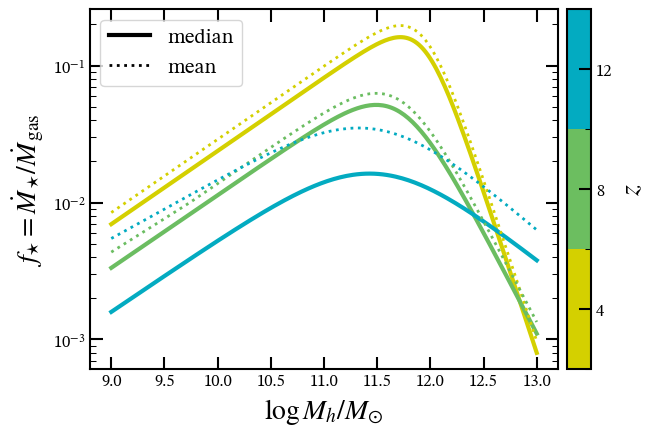

In [138]:
sfe_mean = sfe_with_mean(my_UVLF, fiducial, zs = [4, 8, 12])

In [142]:
sfe_mean.savefig('/Users/eb35267/Desktop/code/figures/sfe_mean_vs_median.png')

In [136]:
def sfe_with_scatter(my_UVLF, param_values, zs = None, Mhtab = None, id_max = False):
    """
    Plot SFE vs. halo mass at different redshifts
    Inputs:
        my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
        param_values [1darray]: values of parameters to calculate SFE
        zs [1darray]: redshifts to plot
        Mhtab [1darray]: log10(Mh) to plot over
        id_max [bool]: Whether or not to identify the maximum SFE at the highest and lowest redshift bin
    Returns:
        fig: A figure showing the SFE over the range of given halo masses & redshifts
    """

    if zs is None:
        zs = np.arange(4, 16, 2)

    if Mhtab is None: 
        Mhtab = np.linspace(9, 13, 200)

    Mhtab_og = my_UVLF.HMFintclass.Mhtab # Save this to reset it later. There's probably a more elegant solution I could come up with at another time
    my_UVLF.HMFintclass.Mhtab = 10**Mhtab # Set the UVLF table of halo masses to the input value
    

    fig = plt.figure(figsize=(6, 4.5))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # narrow right slot for cbar
    ax = fig.add_axes(ax_rect)

    if len(zs)>1:
        cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.yellow, eplots.turquoise], zs)
    
    for z in zs:
        # Calculate parameters at this z
        params = my_UVLF.time_evolution(param_values, z)
        Astro_Parameters = my_UVLF.param_wrapper(params)
        # Calculate SFE
        SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
            Astro_Parameters, my_UVLF.CosmoParams, z, my_UVLF.HMFintclass.Mhtab)
        # Assign color
        if len(zs) > 1:
            frac = (z - min(zs)) / (max(zs) - min(zs))
            color = cmap(frac)
        else:
            color = yellow
        # Plot
        plt.plot(Mhtab, np.log10(SFEs), color = color, ls = '-', zorder = 0)
        
        sigfstar = params[-1] / 2.5
        low_bound, high_bound = np.log10(SFEs)-sigfstar, np.fmin(np.log10(SFEs)+sigfstar, 0)
        ax.fill_between(Mhtab, low_bound, high_bound, color = color, alpha = 0.2)
        plt.plot(Mhtab, low_bound, color = color, ls = 'dotted', lw = 1, zorder = 0)
        plt.plot(Mhtab, high_bound, color = color, ls = 'dotted', lw = 1, zorder = 0)

        if ((z == max(zs) or z==min(zs)) and id_max): # Putting text on the plot indicating the maximum SFE for the highest & lowest redshifts
            max_idx = np.argmax(SFEs) # Maximum /= M_c unless the power law indices are the same!
            plt.scatter(Mhtab[max_idx], SFEs[max_idx], color = color, s = 100, zorder = 1)
            if z==min(zs): # Positioning the text
                x = (Mhtab[max_idx]-0.7)
                y = SFEs[max_idx]-0.01
            else:
                x = Mhtab[max_idx]
                y = 0.6*SFEs[max_idx]
            plt.text(x, y, fr'$f_\star = {round(SFEs[max_idx], 2)}$', color = color, ha = 'center', 
                         va = 'center', size = 17)

    if len(zs)>1:
    # Color bar things:
        cax = fig.add_axes(cax_rect)
        cbar = fig.colorbar(sm, cax=cax, boundaries=boundaries, ticks=zs, aspect = 14)
        cbar.set_label(r'$z$')

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$\log_{10}(f_{\star} = \dot M_{\star} / \dot M_{\rm{gas}})$')

    my_UVLF.HMFintclass.HMFtab = Mhtab_og
        
        
    return fig


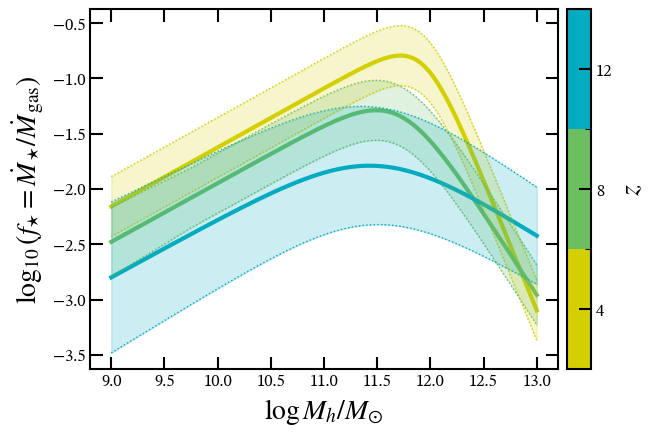

In [140]:
sfe_scatter = sfe_with_scatter(my_UVLF, fiducial, zs = [4, 8, 12])

In [141]:
sfe_scatter.savefig('/Users/eb35267/Desktop/code/figures/sfe_1sig_scatter.png')